In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
demand = pd.read_csv(
    # Path.cwd().parent / 'resources' / 'industrial_energy_demand_base_s_50_2025.csv', index_col=0
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv', index_col=0, header=[0, 1]
)

In [3]:
demand

AL                                 \
            Alumina production Aluminium - primary production   
TWh/a                                                           
ammonia                    0.0                            0.0   
biomass                    0.0                            0.0   
electricity                0.0                            0.0   
gas                        0.0                            0.0   
heat                       0.0                            0.0   
hydrogen                   0.0                            0.0   
liquid                     0.0                            0.0   
other                      0.0                           -0.0   
solid                      0.0                            0.0   
waste                      0.0                            0.0   

                                                                    \
            Aluminium - secondary production Ammonia        Cement   
TWh/a                                                                
ammonia                                  0.0     0.0  0.000000e+00   
biomass                                  0.0     0.0  1.906630e-03   
electricity                              0.0     0.0  2.817006e-03   
gas                                      0.0     0.0  9.535426e-03   
heat                                     0.0     0.0  2.144612e-04   
hydrogen                                 0.0     0.0  0.000000e+00   
liquid                                   0.0     0.0  6.124493e-03   
other                                   -0.0     0.0 -1.255286e-18   
solid                                    0.0     0.0  3.262325e-03   
waste                                    0.0     0.0  4.798959e-03   

                                                          \
            Ceramics & other NMM  Chlorine  Electric arc   
TWh/a                                                      
ammonia             0.000000e+00  0.000000  0.000000e+00   
biomass             1.860580e-03  0.000000  1.745756e-04   
electricity         5.759261e-03  0.011160  6.071055e-02   
gas                 1.285101e-02  0.000000  3.241683e-02   
heat                4.057514e-04  0.000000  2.162600e-03   
hydrogen            0.000000e+00 -0.002905  0.000000e+00   
liquid              5.542503e-03  0.000000  2.096589e-03   
other              -6.306161e-19  0.000000 -2.724209e-18   
solid               3.401920e-03  0.000000  1.406566e-03   
waste               3.604022e-03  0.000000  5.335114e-06   

                                                          ...              XK  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
TWh/a                                                     ...                   
ammonia                    0.000000e+00     0.000000e+00  ...    0.000000e+00   
biomass                    2.959699e-02     3.763335e-05  ...    3.283821e-05   
electricity                2.006112e-01     3.650089e-03  ...    9.666255e-04   
gas                        2.649908e-01     6.422005e-03  ...    1.323223e-03   
heat                       2.977809e-02     0.000000e+00  ...    5.014533e-04   
hydrogen                   0.000000e+00     0.000000e+00  ...    0.000000e+00   
liquid                     3.005989e-02     4.658897e-04  ...    4.316407e-04   
other                      2.431179e-17    -9.447981e-20  ...   -2.187968e-19   
solid                      2.391242e-02     1.656717e-03  ...    2.662675e-04   
waste                      1.536753e-04     0.000000e+00  ...    2.949609e-05   

                                                               \
            Other industrial sectors Other non-ferrous metals   
TWh/a                                                           
ammonia                 0.000000e+00                      0.0   
biomass                 1.848777e-02                      0.0   
electricity             1.937139e-01                      0.0   
gas                     9.114439e-02          

In [4]:
production = pd.read_csv(
    # Path.cwd().parent / 'resources' / 'industrial_production_base_s_50_2025.csv', index_col=0
    Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv', index_col=0
).stack() / 1e3
production.index.names = [None, None]

In [5]:
production

AL  Electric arc                    0.07267
    Integrated steelworks           0.09864
    Other chemicals                 0.00742
    Pharmaceutical products etc.    0.00284
    Cement                          0.03315
                                     ...   
XK  Other industrial sectors        1.41518
    Ammonia                         0.00000
    HVC                             0.00152
    Chlorine                        0.00028
    Methanol                        0.00004
Length: 816, dtype: float64

In [6]:
ratios_tomorrow = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industry_sector_ratios.csv', index_col=0
)

In [7]:
ratios_today = demand.div(production, axis=1).replace([np.inf, -np.inf], 0).dropna(how='all', axis=1)

In [8]:
ratios_tomorrow.index

Index(['elec', 'coal', 'coke', 'biomass', 'methane', 'hydrogen', 'heat',
       'naphtha', 'ammonia', 'methanol', 'process emission',
       'process emission from feedstock'],
      dtype='object', name='MWh/tMaterial')

In [9]:
mapper = {
    'gas': 'methane',
    'liquid': 'naphtha',
    'solid': 'coke',
    'electricity': 'elec',
    'other': 'biomass',
    'waste': 'biomass',
    }

/tmp/ipykernel_1752912/622879381.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  for _, (pair, values) in enumerate((r := ratios_today.stack()).loc[r.std(axis=1).sort_values(ascending=False).index].iterrows()):


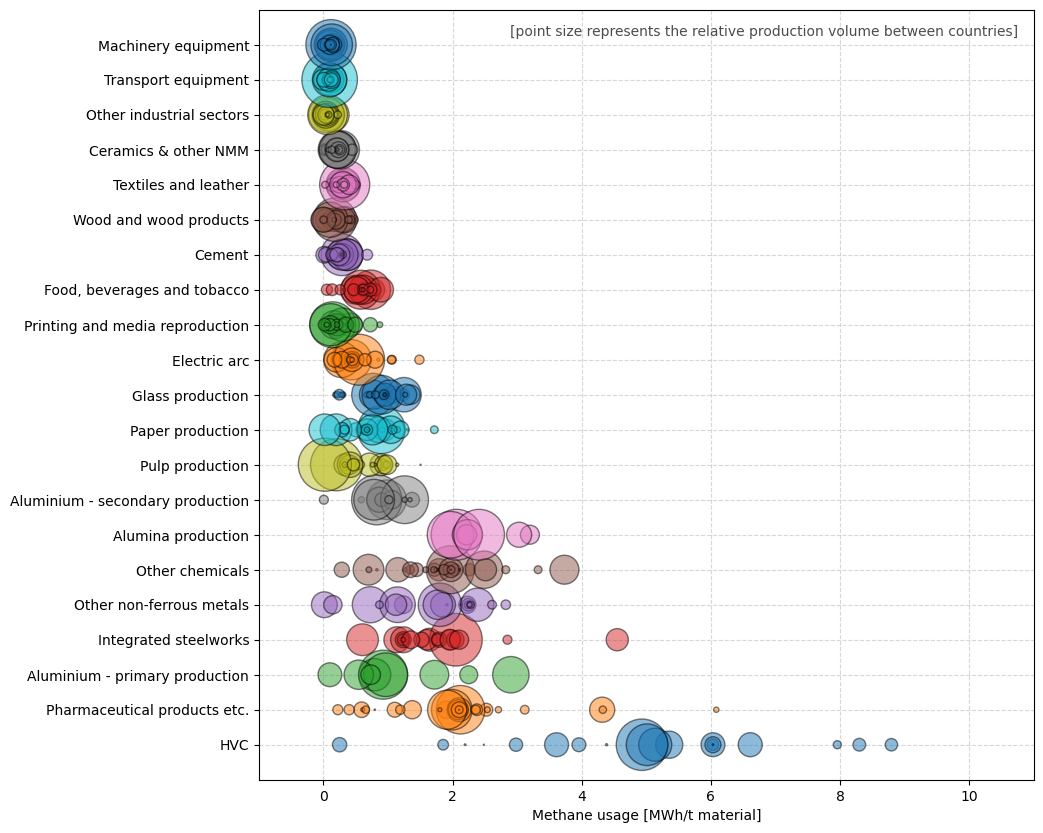

In [10]:
scatter_kwargs = dict(
    s=100,
    alpha=0.5,
    edgecolor='black',
)

country_prod = production.unstack()

fig, ax = plt.subplots(figsize=(10, 10))

i = 0
ytick_labels = []
for _, (pair, values) in enumerate((r := ratios_today.stack()).loc[r.std(axis=1).sort_values(ascending=False).index].iterrows()):

    fuel, product = pair
    if not fuel in 'gas':
        continue

    values = values.loc[~values.isna()]
    y = np.ones(len(values)) * i

    s = country_prod.loc[values.index, product].values
    s = s / s.sum() * 50

    
    ax.scatter(values.values, y, s=s*100, alpha=0.5, edgecolor='black')
    
    # Plot median as blue cross
    median_value = values.median()
    # ax.scatter([median_value], [i], marker='x', color='blue', s=150, linewidths=2)
    
    # Plot mean as green cross
    mean_value = values.mean()
    # ax.scatter([mean_value], [i], marker='x', color='green', s=150, linewidths=2)
    
    tomorrow_value = ratios_tomorrow.loc[mapper.get(fuel, fuel), product]
    # print('tomorrow value', tomorrow_value)

    # ax.scatter([tomorrow_value], [i], marker='x', color='red')

    ytick_labels.append(product)
    i += 1

    if i > 20:
        break

ax.set_xlim(-1, 11)
ax.set_yticks(range(len(ytick_labels)))
ax.set_yticklabels(ytick_labels)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel('Methane usage [MWh/t material]')

ax.text(0.98, 0.98, '[point size represents the relative production volume between countries]', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', 
        horizontalalignment='right', alpha=0.7)


plt.show()

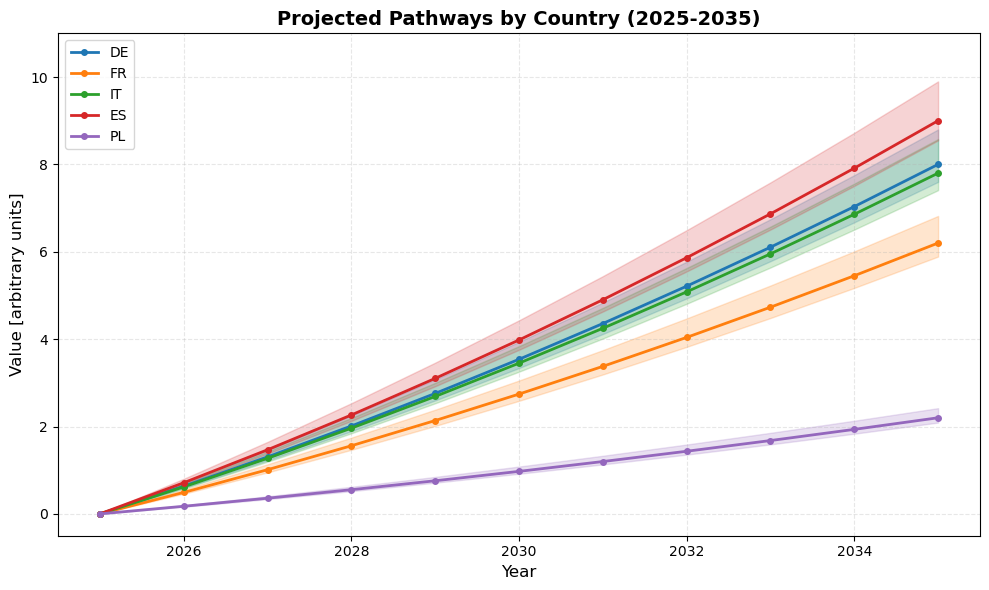

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Define years
years = np.arange(2025, 2036)

# Define countries and their 2035 target values
countries = ['DE', 'FR', 'IT', 'ES', 'PL']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
target_values = [8, 6.2, 7.8, 9, 2.2]  # Random higher values for 2035

# Plot for each country
for country, color, target in zip(countries, colors, target_values):
    # Create slightly curved trajectory (quadratic)
    t = np.linspace(0, 1, len(years))
    central_line = target * (t + 0.3 * t**2) / 1.3  # Slight upward bend
    
    # Create optimistic and pessimistic pathways (cone)
    cone_width = 0.1 * target  # 15% uncertainty
    optimistic = central_line + cone_width * t
    pessimistic = central_line - cone_width * t * 0.5  # Narrower on lower side
    
    # Plot the cone (uncertainty band)
    ax.fill_between(years, pessimistic, optimistic, alpha=0.2, color=color)
    
    # Plot the central line
    ax.plot(years, central_line, color=color, linewidth=2, label=country, marker='o', markersize=4)

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Value [arbitrary units]', fontsize=12)
ax.set_title('Projected Pathways by Country (2025-2035)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', frameon=True, fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(2024.5, 2035.5)
ax.set_ylim(-0.5, 11)

plt.tight_layout()
plt.show()


In [174]:
ss = ratios_today.rename(mapper).groupby(level=0).sum()
ss

AL                                             \
            Cement Ceramics & other NMM Chlorine Electric arc   
TWh/a                                                           
ammonia   0.000000             0.000000   0.0000     0.000000   
biomass   0.202280             0.091780   0.0000     0.002476   
coke      0.098411             0.057137   0.0000     0.019356   
elec      0.084978             0.096729   3.6000     0.835428   
heat      0.006469             0.006815   0.0000     0.029759   
hydrogen  0.000000             0.000000  -0.9372     0.000000   
methane   0.287645             0.215838   0.0000     0.446083   
naphtha   0.184751             0.093089   0.0000     0.028851   

                                                                  \
         Food, beverages and tobacco Glass production        HVC   
TWh/a                                                              
ammonia                     0.000000         0.000000   0.000000   
biomass                     0.069117         0.005575   0.118108   
coke                        0.055553         0.245440   0.487307   
elec                        0.466061         0.540754   1.492222   
heat                        0.069181         0.000000   1.248865   
hydrogen                    0.000000         0.000000   0.006202   
methane                     0.615628         0.951408   6.031179   
naphtha                     0.069835         0.069021  14.398718   

                                                         ...         XK  \
         Integrated steelworks Methanol Other chemicals  ...        HVC   
TWh/a                                                    ...              
ammonia               0.000000    0.000        0.000000  ...   0.000000   
biomass               0.003593    0.000        0.093036  ...   0.118108   
coke                  0.351180    0.000        0.397414  ...   0.487307   
elec                  0.618070    0.167        1.442725  ...   1.492222   
heat                  0.044435    0.000        0.748438  ...   1.248865   
hydrogen              0.000000    0.000        0.000000  ...   0.006202   
methane               1.235546   10.250        1.974960  ...   6.031179   
naphtha               0.039207    0.000        0.644240  ...  14.398718   

                                                                             \
         Integrated steelworks Machinery equipment Methanol Other chemicals   
TWh/a                                                                         
ammonia               0.000000            0.000000    0.000        0.000000   
biomass               0.003593            0.002887    0.000        0.093036   
coke                  0.351180            0.001374    0.000        0.397414   
elec                  0.618070            0.189899    0.167        1.442725   
heat                  0.044435            0.012131    0.000        0.748438   
hydrogen              0.000000            0.000000    0.000        0.000000   
methane               1.235546            0.114248   10.250        1.974960   
naphtha               0.039207            0.017650    0.000        0.644240   

                                                    \
         Other industrial sectors Paper production   
TWh/a                                                
ammonia                  0.000000         0.000000   
biomass                  0.013576         1.020284   
coke                     0.006001         0.083248   
elec                     0.136883         0.508474   
heat                     0.019658         0.242764   
hydrogen                 0.000000         0.000000   
methane                  0.064405         0.674484   
naphtha                  0.089607         0.052100   

                                                                       \
         Pharmaceutical products etc. Printing and media reproduction   
TWh/a                                                                   
ammonia                      0.000000    

In [12]:
ratios = ratios_tomorrow.copy()

In [15]:
production

AL  Electric arc                    0.07267
    Integrated steelworks           0.09864
    Other chemicals                 0.00742
    Pharmaceutical products etc.    0.00284
    Cement                          0.03315
                                     ...   
XK  Other industrial sectors        1.41518
    Ammonia                         0.00000
    HVC                             0.00152
    Chlorine                        0.00028
    Methanol                        0.00004
Length: 816, dtype: float64

In [18]:
production = pd.read_csv(
    # Path.cwd().parent / 'resources' / 'industrial_production_base_s_50_2025.csv', index_col=0
    Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv', index_col=0
) / 1e3
# production.index.names = [None, None]

In [21]:
production

,Electric arc,Integrated steelworks,Other chemicals,Pharmaceutical products etc.,Cement,Ceramics & other NMM,Glass production,Pulp production,Paper production,Printing and media reproduction,...,Other non-ferrous metals,Transport equipment,Machinery equipment,Textiles and leather,Wood and wood products,Other industrial sectors,Ammonia,HVC,Chlorine,Methanol
kton/a,,,,,,,,,,,,,,,,,,,,,
AL,0.07267,0.09864,0.00742,0.00284,0.03315,0.05954,0.00675,0.01168,0.02639,0.00303,...,0.00000,0.00000,0.00000,0.27317,0.00409,1.11877,0.00000,0.01680,0.00310,0.00048
AT,0.70923,6.71429,0.47635,0.19738,4.51695,9.96166,0.76562,2.09027,4.98471,0.23583,...,0.41793,4.53323,17.87055,1.15796,2.39198,28.33384,0.55250,0.87938,0.16201,0.02537
BA,0.59714,0.81050,0.00983,0.00377,0.89984,1.61627,0.18326,0.03016,0.06816,0.00782,...,0.00000,0.22613,1.13002,0.37998,0.09183,1.24488,0.00000,0.02226,0.00410,0.00064
BE,2.52000,5.23954,1.52666,0.36553,5.83421,13.77226,1.39907,0.51498,1.93511,0.61252,...,1.86150,4.22466,9.65464,3.00512,1.00379,23.76091,1.05643,4.20756,0.77516,0.12137
BG,0.56590,0.00000,0.52590,0.09036,2.37146,4.57770,0.61227,0.23879,0.36397,0.03692,...,0.44836,0.62906,4.65630,1.10623,0.29234,8.59773,0.27929,0.37498,0.06908,0.01082
CH,0.44639,0.60588,0.33051,0.12667,1.63726,2.94082,0.33344,0.26507,0.59899,0.06871,...,0.00000,13.60409,3.58444,0.63909,0.00000,8.03298,0.01700,0.73562,0.13552,0.02122
CZ,0.23402,4.20281,0.57946,0.28720,4.56938,10.72442,1.17904,0.55687,0.88212,0.20051,...,0.22500,19.52745,23.65622,2.21173,0.89371,21.34952,0.15786,1.00495,0.18514,0.02899
DE,11.90528,27.72207,7.14299,2.78819,34.18534,53.30138,7.37761,2.32596,22.08004,2.32565,...,2.68134,108.81003,176.04491,7.44029,7.24744,125.71677,2.93250,15.05210,2.77306,0.43420
DK,0.50410,0.00000,0.43482,0.26589,2.44060,7.20954,0.20262,0.00483,0.29874,0.04272,...,0.00000,0.52980,7.02930,0.29355,0.33588,14.79159,0.00000,0.00000,0.00000,0.00000


In [28]:
total = ratios.loc['methane'].mul(production.sum().mul(ratios.loc['methane']).sort_values())
total = total.loc[total > 0]

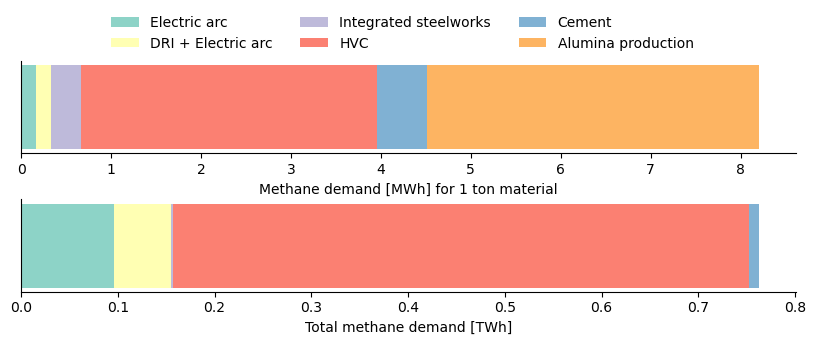

In [30]:
fig = plt.figure(figsize=(10, 3))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.5)
axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

colors = plt.cm.Set3(np.linspace(0, 1, 12))

labels = []
handles = []

left_edge = 0.
color_idx = 0
for name, value in ratios.loc['methane'].items():
    if value == 0.0:
        continue

    labels.append(name)
    handles.append(axs[0].barh(0, value, left=left_edge, color=colors[color_idx % len(colors)]))
    left_edge += value
    color_idx += 1


axs[0].legend(
    handles,
    labels,
    frameon=False,
    ncols=len(labels)//2,
    loc='center left',
    bbox_to_anchor=(0.1, 1.3)
)

axs[0].set_xlabel('Methane demand [MWh] for 1 ton material')
axs[1].set_xlabel('Total methane demand [TWh]')

left_edge = 0.
color_idx = 0
for name, value in total.items():

    axs[1].barh(0, value * 1e-3, left=left_edge, color=colors[color_idx % len(colors)])
    left_edge += value * 1e-3
    color_idx += 1


for ax in axs:
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

In [81]:
import sys
sys.path.append(
    str(Path.cwd().parent / 'scripts')
)
sys.path.append(
    str(Path.cwd().parent)
)
from build_industry_sector_ratios import (
    cc,
    toe_to_MWh,
    eu27,
    sheet_names,
    index,
)
from _helpers import mute_print

In [84]:
def load_idees_data(sector, country="EU27"):
    suffixes = {"out": "", "fec": "_fec", "ued": "_ued", "emi": "_emi"}
    sheets = {k: sheet_names[sector] + v for k, v in suffixes.items()}

    year = 2021

    def usecols(x):
        return isinstance(x, str) or x == year

    with mute_print():
        idees = pd.read_excel(
            Path.cwd().parent / 'data' / 'jrc-idees-2021' / "DE/JRC-IDEES-2021_Industry_DE.xlsx",
            sheet_name=list(sheets.values()),
            index_col=0,
            header=0,
            usecols=usecols,
        )

    for k, v in sheets.items():
        idees[k] = idees.pop(v).squeeze()
        idees[k] = idees[k][year]

    return idees

In [ ]:
def get_chemical_industry_composition():

    sector = "Chemicals Industry"
    idees = load_idees_data(sector)

    names = []
    demands = []






get_chemical_industry_composition()

In [33]:
years = [2025, 2030, 2035]

fn = str(
    Path.cwd().parent / 'resources' / 'industry_sector_ratios_{}.csv'
)

In [74]:
idx = pd.IndexSlice

methane_uses = list()


for y in years:
    ratios = pd.read_csv(fn.format(y), index_col=0, header=[0, 1])
    prod = pd.read_csv(
        Path.cwd().parent / 'resources' / 'industrial_production_per_country_tomorrow_{}.csv'.format(y), index_col=0
    )
    total = ratios.T.mul(prod.stack().loc[ratios.columns], axis=0).groupby(level=1).sum().T.mul(1e3/1e6)
    total.index.name = 'TWh/a'

    methane_uses.append(total.loc['methane'].rename(y))

In [84]:
total = pd.concat(methane_uses, axis=1)
total = total.loc[total.sum(axis=1).sort_values(ascending=False).index]
total

,2025,2030,2035
HVC,260.222192,223.338688,177.318879
"Food, beverages and tobacco",160.223393,134.924962,92.760912
Integrated steelworks,156.191335,115.279328,67.605425
Cement,56.898917,64.517449,77.215002
Machinery equipment,72.860419,61.356142,42.182348
Ceramics & other NMM,70.098705,59.030488,40.583461
Other industrial sectors,63.727645,53.665385,36.894952
Paper production,59.721403,50.291708,34.575549
Other chemicals,56.068501,47.215580,32.460711
Electric arc,32.144231,31.762980,28.486889


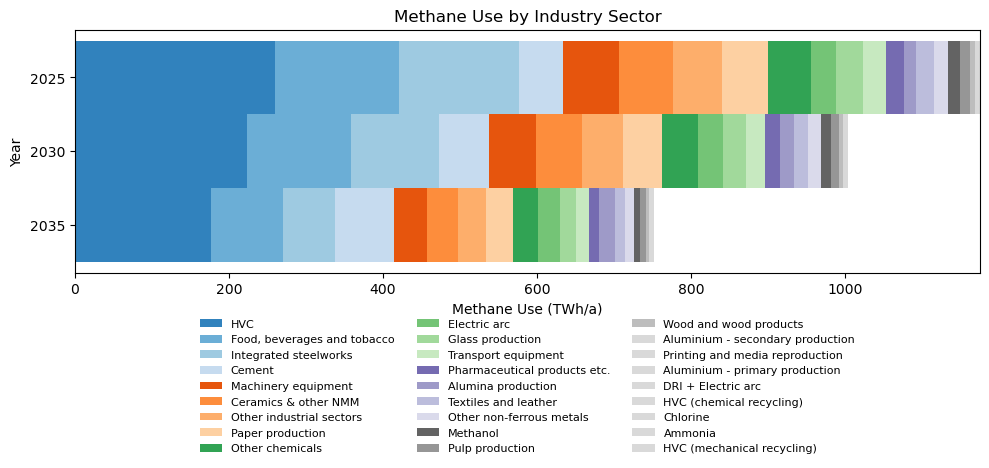

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))


colors = plt.cm.tab20c(range(len(total)))


bar_height = 1.0
y_positions = [0, -bar_height, -bar_height * 2]


left = [0, 0, 0]  # Starting position for each year

for idx, industry in enumerate(total.index):
    values = total.loc[industry].values
    ax.barh(y_positions, values, bar_height, left=left, 
            label=industry, color=colors[idx % len(colors)])
    left = [l + v for l, v in zip(left, values)]


ax.set_yticks(y_positions)
ax.set_yticklabels(years)
ax.set_xlabel('Methane Use (TWh/a)')
ax.set_ylabel('Year')
ax.set_title('Methane Use by Industry Sector')


ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=3, frameon=False, fontsize=8)


plt.tight_layout()


plt.show()

In [88]:
ratios_tomorrow

,Electric arc,DRI + Electric arc,Integrated steelworks,HVC,HVC (mechanical recycling),HVC (chemical recycling),Ammonia,Chlorine,Methanol,Other chemicals,...,"Food, beverages and tobacco",Alumina production,Aluminium - primary production,Aluminium - secondary production,Other non-ferrous metals,Transport equipment,Machinery equipment,Textiles and leather,Wood and wood products,Other industrial sectors
MWh/tMaterial,,,,,,,,,,,,,,,,,,,,,
elec,1.122141,1.444141,1.031528,2.453750,0.547,6.9,0.000,3.6000,0.000,5.070319,...,0.612683,1.392549,14.760581,1.628537,3.240152,0.228642,0.256673,0.304701,0.855880,0.241559
coal,0.000000,0.000000,0.154117,0.000000,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
coke,0.000000,0.000000,0.184750,0.000000,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
biomass,0.000000,0.000000,0.000000,0.000000,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.649137,0.000000,0.000000,0.000000,0.000000,0.065861,0.065072,0.268927,1.825742,0.070888
methane,0.166574,0.166574,0.332487,3.294687,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,3.689891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hydrogen,0.000000,1.700000,0.000000,0.172661,0.000,0.0,0.000,-0.9372,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
heat,0.004511,0.004511,0.005748,0.181899,0.000,0.0,0.000,0.0000,0.000,0.154505,...,0.028678,0.015394,0.044652,0.005198,0.013510,0.008214,0.009244,0.056121,0.055191,0.007617
naphtha,0.000000,0.000000,0.000000,12.622583,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ammonia,0.000000,0.000000,0.000000,0.000000,0.000,0.0,5.166,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [55]:
a = pd.DataFrame(index=[1,2,3], columns=['a', 'b', 'c'])
b = pd.Series(index=['a', 'b', 'c'])

In [57]:
a.T.mul(b, axis=0).T

,a,b,c
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN


In [ ]:

.imul(prod.stack(), axis=0).T

In [50]:
prod.stack().index

MultiIndex([('AL',                 'Electric arc'),
            ('AL',        'Integrated steelworks'),
            ('AL',           'DRI + Electric arc'),
            ('AL',              'Other chemicals'),
            ('AL', 'Pharmaceutical products etc.'),
            ('AL',                       'Cement'),
            ('AL',         'Ceramics & other NMM'),
            ('AL',             'Glass production'),
            ('AL',              'Pulp production'),
            ('AL',             'Paper production'),
            ...
            ('XK',          'Machinery equipment'),
            ('XK',         'Textiles and leather'),
            ('XK',       'Wood and wood products'),
            ('XK',     'Other industrial sectors'),
            ('XK',                      'Ammonia'),
            ('XK',                          'HVC'),
            ('XK',                     'Chlorine'),
            ('XK',                     'Methanol'),
            ('XK',   'HVC (mechanical recycling)

In [ ]:
ratios.columns

MultiIndex([('AL',                     'Electric arc'),
            ('AL',               'DRI + Electric arc'),
            ('AL',            'Integrated steelworks'),
            ('AL',                              'HVC'),
            ('AL',       'HVC (mechanical recycling)'),
            ('AL',         'HVC (chemical recycling)'),
            ('AL',                          'Ammonia'),
            ('AL',                         'Chlorine'),
            ('AL',                         'Methanol'),
            ('AL',                  'Other chemicals'),
            ...
            ('XK',      'Food, beverages and tobacco'),
            ('XK',               'Alumina production'),
            ('XK',   'Aluminium - primary production'),
            ('XK', 'Aluminium - secondary production'),
            ('XK',         'Other non-ferrous metals'),
            ('XK',              'Transport equipment'),
            ('XK',              'Machinery equipment'),
            ('XK',             '